# Tarea No. 2 — Red neuronal para predecir la Personalidad

Red neuronal con **2 capas ocultas (64 y 32 neuronas)** para predecir la variable
`Personality` (Extrovert/Introvert) a partir de los atributos del dataset
`personality_dataset.csv` (ubicado en la carpeta `tarea_2_3`). Entrenada con PyTorch
usando MPS (GPU del chip de Apple) o CUDA en Colab.

In [ ]:
# Carga de las dependencias que vamos a emplear
import numpy as np
import pandas as pd

# Para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Dependencias de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dependencias de Pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
# Identificar el dispositivo con el que estamos trabajando
# MPS (chip de Apple en Mac) -> CUDA (Colab con GPU) -> CPU
device = ('mps' if torch.backends.mps.is_available() else
          'cuda' if torch.cuda.is_available() else 'cpu')
device

## Resolución Tarea No. 2

Red neuronal con **2 capas ocultas (64 y 32 neuronas)** para predecir la variable
`Personality` (Extrovert/Introvert) a partir de los atributos del dataset
`personality_dataset.csv` (ubicado en esta misma carpeta, `tarea_2_3`).

In [25]:
# Cargar el dataset de personalidad
import os
file = 'personality_dataset.csv' if os.path.exists('personality_dataset.csv') else os.path.join('tarea_2_3', 'personality_dataset.csv')
datos = pd.read_csv(file)
print(f'Dimensiones: {datos.shape[0]} registros y {datos.shape[1]} variables')
print(f'Valores nulos: {int(datos.isna().sum().sum())}')
print(f'Duplicados: {int(datos.duplicated().sum())}')

# Limpieza: eliminar duplicados y registros con valores nulos
datos = datos.drop_duplicates()
datos = datos.dropna()
print(f'Dimensiones después de la limpieza: {datos.shape[0]} registros')

# Balance de la variable objetivo
datos['Personality'].value_counts()

Dimensiones: 2900 registros y 8 variables
Valores nulos: 458
Duplicados: 388
Dimensiones después de la limpieza: 2098 registros


Personality
Extrovert    1201
Introvert     897
Name: count, dtype: int64

In [26]:
# Selección del Target (Personality) y de los Atributos
# Extrovert -> 1, Introvert -> 0
y = (datos['Personality'] == 'Extrovert').astype(float).values
X = datos.drop('Personality', axis=1)

In [27]:
# Partición: 80% train, 10% val, 10% test
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, train_size=0.80, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)

# Preprocesamiento: numéricas -> StandardScaler; categóricas -> OneHotEncoder
col_num = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
col_cat = ['Stage_fear', 'Drained_after_socializing']
col_transform = ColumnTransformer([
    ('num', StandardScaler(), col_num),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), col_cat),
])
X_train = col_transform.fit_transform(X_train)
X_val = col_transform.transform(X_val)
X_test = col_transform.transform(X_test)
print(f'Características de entrada: {X_train.shape[1]}')

Características de entrada: 7


In [28]:
# Convertir a Tensor y subir al device (MPS en Mac)
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
X_val   = torch.tensor(X_val,   dtype=torch.float32, device=device)
X_test  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_train = torch.tensor(y_train, dtype=torch.float32, device=device)
y_val   = torch.tensor(y_val,   dtype=torch.float32, device=device)
y_test  = torch.tensor(y_test,  dtype=torch.float32, device=device)

# Red neuronal con 2 capas ocultas: 64 y 32 neuronas (como pide la tarea)
torch.manual_seed(42)
modelo = nn.Sequential(
    nn.Linear(X_train.shape[1], 64), nn.ReLU(),  # Primera capa oculta
    nn.Linear(64, 32), nn.ReLU(),                # Segunda capa oculta
    nn.Linear(32, 1), nn.Sigmoid(),
).to(device)

loss_fn = nn.BCELoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

In [29]:
# Entrenamiento con monitoreo de pérdida y accuracy
n_epochs = 1000
loss_train, loss_val = [], []
acc_train, acc_val = [], []

for epochs in range(n_epochs):
    modelo.train()
    y_pred_train = modelo(X_train)
    loss = loss_fn(y_pred_train, y_train.view(-1, 1))
    loss_train.append(loss.detach().cpu().numpy())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    acc = ((y_pred_train.round() == y_train.view(-1, 1)).sum() / y_train.size(0) * 100).item()
    acc_train.append(acc)

    with torch.no_grad():
        y_pred_val = modelo(X_val)
        loss = loss_fn(y_pred_val, y_val.view(-1, 1))
        loss_val.append(loss.detach().cpu().numpy())
        acc = ((y_pred_val.round() == y_val.view(-1, 1)).sum() / y_val.size(0) * 100).item()
        acc_val.append(acc)

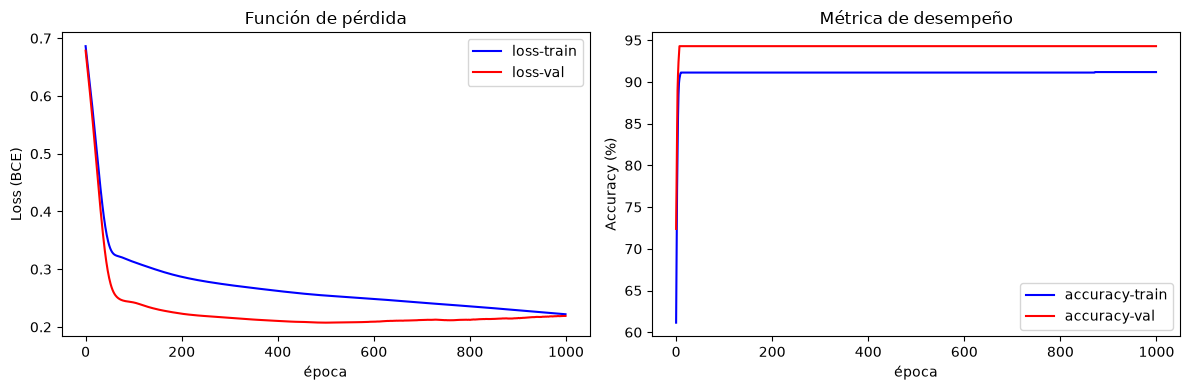

Loss train final: 0.2220 | Loss val final: 0.2190
Accuracy train final: 91.18% | Accuracy val final: 94.29%


In [30]:
# Monitoreo de la evolución del modelo (pérdida y accuracy)
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].plot(range(n_epochs), loss_train, label='loss-train', color='Blue')
ejes[0].plot(range(n_epochs), loss_val, label='loss-val', color='Red')
ejes[0].set_xlabel('época'); ejes[0].set_ylabel('Loss (BCE)')
ejes[0].set_title('Función de pérdida'); ejes[0].legend()
ejes[1].plot(range(n_epochs), acc_train, label='accuracy-train', color='Blue')
ejes[1].plot(range(n_epochs), acc_val, label='accuracy-val', color='Red')
ejes[1].set_xlabel('época'); ejes[1].set_ylabel('Accuracy (%)')
ejes[1].set_title('Métrica de desempeño'); ejes[1].legend()
plt.tight_layout()
plt.show()

print(f"Loss train final: {float(loss_train[-1]):.4f} | Loss val final: {float(loss_val[-1]):.4f}")
print(f"Accuracy train final: {acc_train[-1]:.2f}% | Accuracy val final: {acc_val[-1]:.2f}%")

In [31]:
# Evaluación en el conjunto de prueba
from sklearn.metrics import confusion_matrix, classification_report

with torch.no_grad():
    y_pred = modelo(X_test)
    loss = loss_fn(y_pred, y_test.view(-1, 1))
    y_pred_bin = y_pred.round().detach().cpu().numpy().ravel()
y_test_np = y_test.detach().cpu().numpy().ravel()
acc_test = (y_pred_bin == y_test_np).mean() * 100

print('Loss:', loss)
print(f'Accuracy en test: {acc_test:.2f}%')
print()
print('Matriz de confusión (filas = real, columnas = predicción):')
print(confusion_matrix(y_test_np, y_pred_bin))
print()
print(classification_report(y_test_np, y_pred_bin, target_names=['Introvert', 'Extrovert'], digits=3))

Loss: tensor(0.2374, device='mps:0')
Accuracy en test: 91.43%

Matriz de confusión (filas = real, columnas = predicción):
[[ 92   6]
 [ 12 100]]

              precision    recall  f1-score   support

   Introvert      0.885     0.939     0.911        98
   Extrovert      0.943     0.893     0.917       112

    accuracy                          0.914       210
   macro avg      0.914     0.916     0.914       210
weighted avg      0.916     0.914     0.914       210



### Resultado de la Tarea No. 2

- Accuracy en **entrenamiento**: 91.18% | **validación**: 94.29% | **prueba**: 91.43%
- Pérdida (BCE) en prueba: 0.2374
- El modelo **no está sobreentrenado**: la pérdida de validación sigue de cerca a la de
  entrenamiento y la accuracy en prueba (91.43%) es consistente con la de validación.